# Airline Passenger Satisfaction Prediction Using ANN
## Model Explainability — Understanding Why the ANN Makes Predictions

In [1]:
#Step 2: Importing the Libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.inspection import permutation_importance
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Libraries imported successfully.")

Libraries imported successfully.


In [ ]:
#Step 3: Setting the Random Seed

np.random.seed(42)
tf.random.set_seed(42)

print("Random seed set to 42.")

Random seed set to 42.


In [3]:
#Step 4: Loading the Processed Data

X_train = np.load("../data/processed/X_train.npy")
y_train = np.load("../data/processed/y_train.npy")

X_val = np.load("../data/processed/X_val.npy")
y_val = np.load("../data/processed/y_val.npy")

X_test = np.load("../data/processed/X_test.npy")
y_test = np.load("../data/processed/y_test.npy")

print("Training data shape:", X_train.shape)
print("Validation data shape:", X_val.shape)
print("Test data shape:", X_test.shape)

Training data shape: (83123, 27)
Validation data shape: (20781, 27)
Test data shape: (25976, 27)


In [4]:
#Step 5: Loading Feature Names

feature_names = np.load(
    "../data/processed/feature_names.npy",
    allow_pickle=True
)

feature_names = np.array(feature_names)

print("Number of features:", len(feature_names))
print("\nFirst 20 features:")
print(feature_names[:20])

Number of features: 27

First 20 features:
['numerical__Age' 'numerical__Flight Distance'
 'numerical__Inflight wifi service'
 'numerical__Departure/Arrival time convenient'
 'numerical__Ease of Online booking' 'numerical__Gate location'
 'numerical__Food and drink' 'numerical__Online boarding'
 'numerical__Seat comfort' 'numerical__Inflight entertainment'
 'numerical__On-board service' 'numerical__Leg room service'
 'numerical__Baggage handling' 'numerical__Checkin service'
 'numerical__Inflight service' 'numerical__Cleanliness'
 'numerical__Departure Delay in Minutes'
 'numerical__Arrival Delay in Minutes' 'categorical__Gender_Female'
 'categorical__Gender_Male']


In [5]:
#Step 6: Checking Feature Alignment

if X_test.shape[1] != len(feature_names):
    raise ValueError(
        f"Feature mismatch: X_test has {X_test.shape[1]} features "
        f"but feature_names has {len(feature_names)} names."
    )

print("Feature names are correctly aligned with the processed data.")

Feature names are correctly aligned with the processed data.


In [6]:
#Step 7: Loading the Optimized ANN Model

model_path = "../models/optimization/optimized_airline_satisfaction_ann.keras"

model = tf.keras.models.load_model(model_path)

print("Optimized ANN loaded successfully.")

Optimized ANN loaded successfully.


In [7]:
#Step 8: Displaying the Model Architecture
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 128)            │         3,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 41,861 (163.52 KB)

 Trainable params: 13,953 (54.50 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 27,908 (109.02 KB)

In [8]:
#Step 9: Creating a Prediction Function
def predict_proba(X):
    return model.predict(X, verbose=0).ravel()

In [9]:
#Step 10: Checking Test Predictions
test_probabilities = predict_proba(X_test)

test_predictions = (
    test_probabilities >= 0.5
).astype(int)

print("Prediction probabilities shape:", test_probabilities.shape)
print("Predictions shape:", test_predictions.shape)

Prediction probabilities shape: (25976,)
Predictions shape: (25976,)


In [10]:
#Step 11: Evaluating the Optimized Model
accuracy = accuracy_score(y_test, test_predictions)

precision = precision_score(
    y_test,
    test_predictions,
    zero_division=0
)

recall = recall_score(
    y_test,
    test_predictions,
    zero_division=0
)

f1 = f1_score(
    y_test,
    test_predictions,
    zero_division=0
)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Accuracy : 0.9641
Precision: 0.9717
Recall   : 0.9458
F1 Score : 0.9586


In [11]:
#Step 12: Creating the Explainability Dataset
EXPLAIN_SAMPLE_SIZE = min(5000, len(X_test))

rng = np.random.default_rng(42)

explain_indices = rng.choice(
    len(X_test),
    size=EXPLAIN_SAMPLE_SIZE,
    replace=False
)

X_explain = X_test[explain_indices]
y_explain = y_test[explain_indices]

print("Explainability sample shape:", X_explain.shape)
print("Explainability target shape:", y_explain.shape)

Explainability sample shape: (5000, 27)
Explainability target shape: (5000,)


In [12]:
#Step 13: Creating the Baseline F1 Score
baseline_probabilities = predict_proba(X_explain)

baseline_predictions = (
    baseline_probabilities >= 0.5
).astype(int)

baseline_f1 = f1_score(
    y_explain,
    baseline_predictions,
    zero_division=0
)

print(f"Baseline F1 Score: {baseline_f1:.4f}")

Baseline F1 Score: 0.9569


#Step 14: Understanding Permutation Importance

Permutation importance measures how much model performance decreases
when one feature's values are randomly shuffled.

If shuffling a feature causes a large performance drop,
that feature is important to the model.

Therefore:

Higher importance → stronger contribution to model predictions.

In [14]:
#Step 15: Creating the F1 Scoring Function
def ann_f1_scorer(estimator, X, y):
    probabilities = estimator.predict(X, verbose=0).ravel()

    predictions = (
        probabilities >= 0.5
    ).astype(int)

    return f1_score(
        y,
        predictions,
        zero_division=0
    )

In [17]:
#Step 16: Creating the ANN Wrapper

from sklearn.base import BaseEstimator, ClassifierMixin


class ANNWrapper(BaseEstimator, ClassifierMixin):

    def __init__(self, keras_model):
        self.keras_model = keras_model

    def fit(self, X, y):
        return self

    def predict(self, X):
        probabilities = self.keras_model.predict(
            X,
            verbose=0
        ).ravel()

        return (
            probabilities >= 0.5
        ).astype(int)

In [18]:
#Step 17: Running Permutation Importance

ann_wrapper = ANNWrapper(model)

perm_result = permutation_importance(
    ann_wrapper,
    X_explain,
    y_explain,
    scoring="f1",
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

print("Permutation importance calculated successfully.")

Permutation importance calculated successfully.


In [19]:
#Step 18: Creating the Feature Importance DataFrame
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance_Mean": perm_result.importances_mean,
    "Importance_STD": perm_result.importances_std
})

importance_df = importance_df.sort_values(
    by="Importance_Mean",
    ascending=False
).reset_index(drop=True)

importance_df.head(15)

,Feature,Importance_Mean,Importance_STD
0,numerical__Inflight wifi service,0.283254,0.002518
1,categorical__Type of Travel_Personal Travel,0.177880,0.002962
2,numerical__Gate location,0.111547,0.003294
3,categorical__Customer Type_disloyal Customer,0.099080,0.003560
4,numerical__Baggage handling,0.039182,0.002151
5,numerical__Inflight service,0.031710,0.001233
6,numerical__Online boarding,0.027687,0.002664
7,numerical__Seat comfort,0.024897,0.001704
8,numerical__Checkin service,0.018952,0.001254
9,categorical__Class_Eco,0.014760,0.001022


In [20]:
#Step 19: Handling Negative Importance Values
importance_df["Positive_Importance"] = (
    importance_df["Importance_Mean"].clip(lower=0)
)

importance_df.head(15)

,Feature,Importance_Mean,Importance_STD,Positive_Importance
0,numerical__Inflight wifi service,0.283254,0.002518,0.283254
1,categorical__Type of Travel_Personal Travel,0.177880,0.002962,0.177880
2,numerical__Gate location,0.111547,0.003294,0.111547
3,categorical__Customer Type_disloyal Customer,0.099080,0.003560,0.099080
4,numerical__Baggage handling,0.039182,0.002151,0.039182
5,numerical__Inflight service,0.031710,0.001233,0.031710
6,numerical__Online boarding,0.027687,0.002664,0.027687
7,numerical__Seat comfort,0.024897,0.001704,0.024897
8,numerical__Checkin service,0.018952,0.001254,0.018952
9,categorical__Class_Eco,0.014760,0.001022,0.014760


In [21]:
#Step 20: Selecting the Top 15 Features
top_features = importance_df.head(15).copy()

top_features

,Feature,Importance_Mean,Importance_STD,Positive_Importance
0,numerical__Inflight wifi service,0.283254,0.002518,0.283254
1,categorical__Type of Travel_Personal Travel,0.177880,0.002962,0.177880
2,numerical__Gate location,0.111547,0.003294,0.111547
3,categorical__Customer Type_disloyal Customer,0.099080,0.003560,0.099080
4,numerical__Baggage handling,0.039182,0.002151,0.039182
5,numerical__Inflight service,0.031710,0.001233,0.031710
6,numerical__Online boarding,0.027687,0.002664,0.027687
7,numerical__Seat comfort,0.024897,0.001704,0.024897
8,numerical__Checkin service,0.018952,0.001254,0.018952
9,categorical__Class_Eco,0.014760,0.001022,0.014760


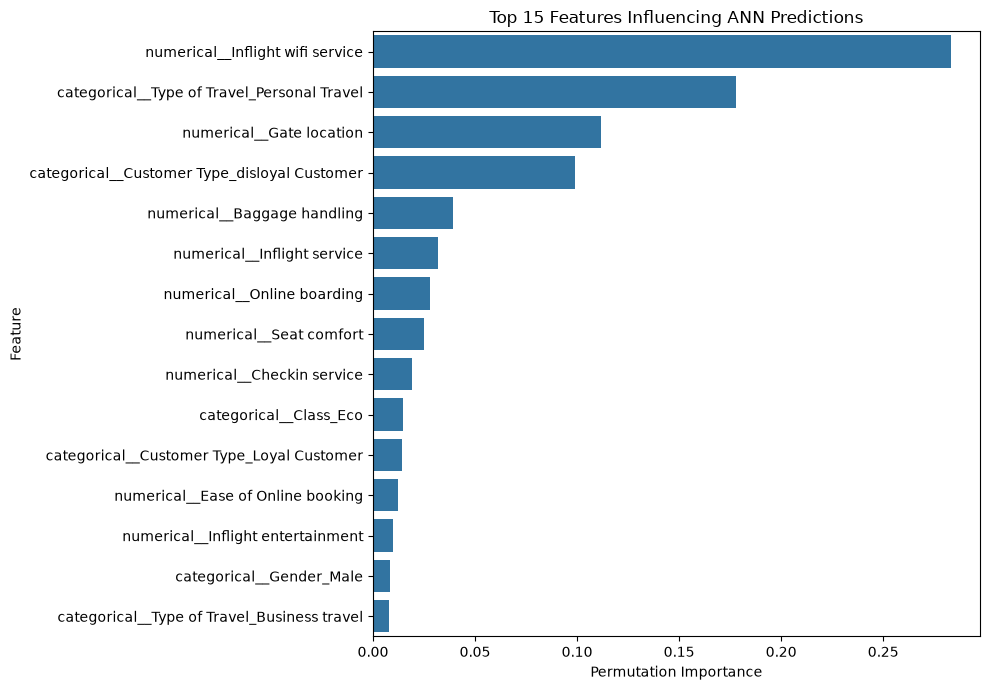

In [22]:
#Step 21: Visualizing Feature Importance
plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_features,
    x="Positive_Importance",
    y="Feature"
)

plt.title("Top 15 Features Influencing ANN Predictions")
plt.xlabel("Permutation Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [23]:
#Step 22: Ranking the Most Important Features
print("Top 10 Most Important Features:\n")

for rank, feature in enumerate(
    importance_df.head(10)["Feature"],
    start=1
):
    print(f"{rank}. {feature}")

Top 10 Most Important Features:

1. numerical__Inflight wifi service
2. categorical__Type of Travel_Personal Travel
3. numerical__Gate location
4. categorical__Customer Type_disloyal Customer
5. numerical__Baggage handling
6. numerical__Inflight service
7. numerical__Online boarding
8. numerical__Seat comfort
9. numerical__Checkin service
10. categorical__Class_Eco


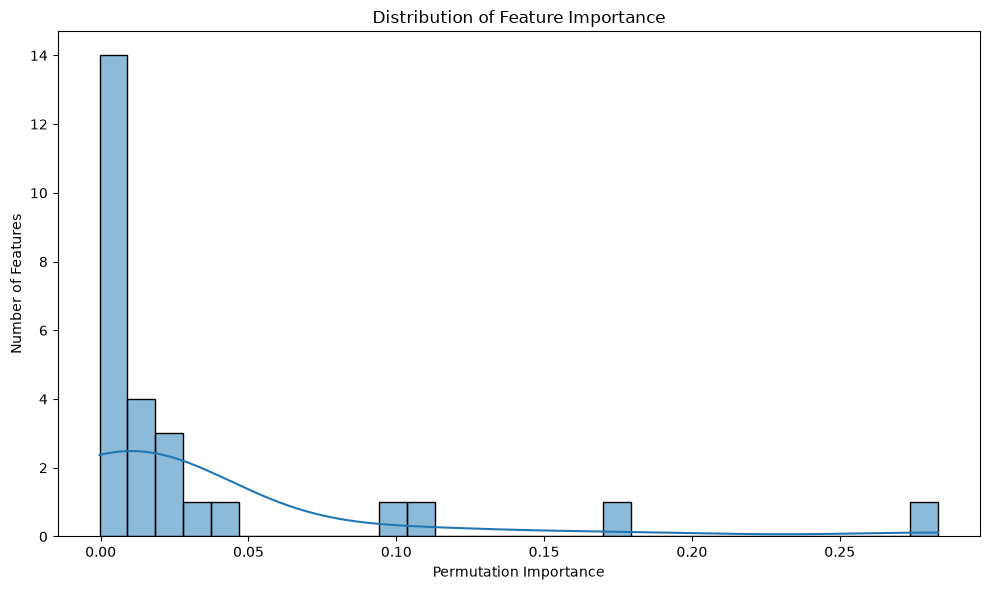

In [24]:
#Step 23: Checking the Importance Distribution
plt.figure(figsize=(10, 6))

sns.histplot(
    importance_df["Importance_Mean"],
    bins=30,
    kde=True
)

plt.title("Distribution of Feature Importance")
plt.xlabel("Permutation Importance")
plt.ylabel("Number of Features")

plt.tight_layout()
plt.show()

In [25]:
#Step 24: Calculating Cumulative Feature Importance
importance_df["Cumulative_Importance"] = (
    importance_df["Positive_Importance"].cumsum()
)

total_importance = importance_df["Positive_Importance"].sum()

if total_importance > 0:

    importance_df["Cumulative_Percentage"] = (
        importance_df["Cumulative_Importance"]
        / total_importance
        * 100
    )

else:

    importance_df["Cumulative_Percentage"] = 0

importance_df.head(15)

,Feature,Importance_Mean,Importance_STD,Positive_Importance,Cumulative_Importance,Cumulative_Percentage
0,numerical__Inflight wifi service,0.283254,0.002518,0.283254,0.283254,30.714055
1,categorical__Type of Travel_Personal Travel,0.177880,0.002962,0.177880,0.461135,50.002128
2,numerical__Gate location,0.111547,0.003294,0.111547,0.572681,62.097443
3,categorical__Customer Type_disloyal Customer,0.099080,0.003560,0.099080,0.671761,72.840930
4,numerical__Baggage handling,0.039182,0.002151,0.039182,0.710943,77.089524
5,numerical__Inflight service,0.031710,0.001233,0.031710,0.742653,80.527942
6,numerical__Online boarding,0.027687,0.002664,0.027687,0.770340,83.530086
7,numerical__Seat comfort,0.024897,0.001704,0.024897,0.795236,86.229692
8,numerical__Checkin service,0.018952,0.001254,0.018952,0.814188,88.284708
9,categorical__Class_Eco,0.014760,0.001022,0.014760,0.828949,89.885223


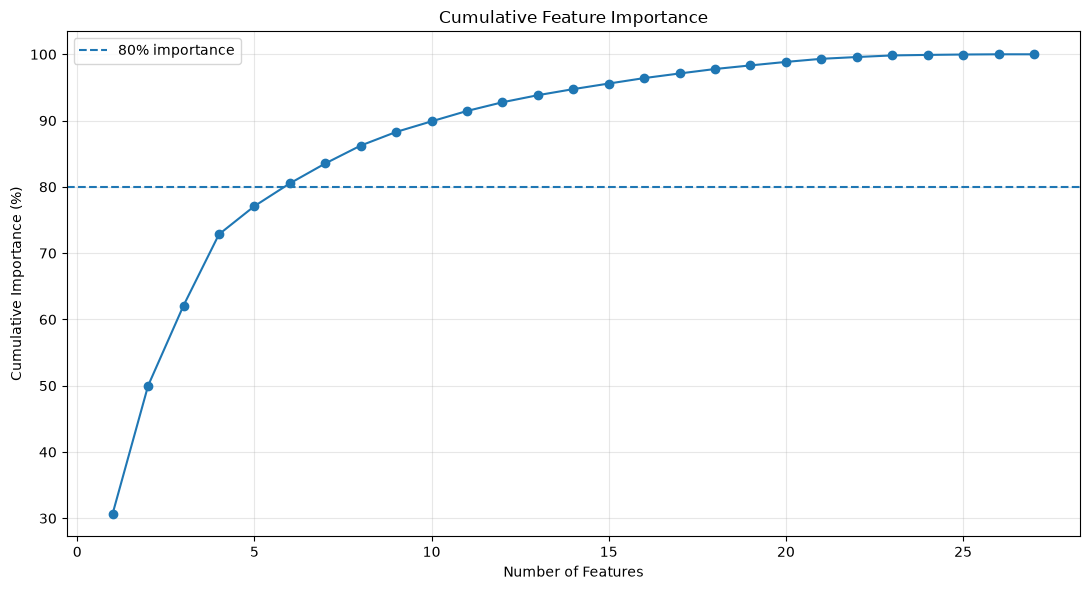

In [26]:
#Step 25: Plotting Cumulative Feature Importance
plt.figure(figsize=(11, 6))

plt.plot(
    range(1, len(importance_df) + 1),
    importance_df["Cumulative_Percentage"],
    marker="o"
)

plt.axhline(
    80,
    linestyle="--",
    label="80% importance"
)

plt.xlabel("Number of Features")
plt.ylabel("Cumulative Importance (%)")
plt.title("Cumulative Feature Importance")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [27]:
#Step 26: Selecting an Individual Passenger
passenger_index = 0

passenger = X_test[
    passenger_index:passenger_index + 1
]

passenger_probability = predict_proba(
    passenger
)[0]

passenger_prediction = int(
    passenger_probability >= 0.5
)

actual_class = int(
    y_test[passenger_index]
)

print("Passenger index:", passenger_index)
print(
    f"Predicted probability of satisfaction: "
    f"{passenger_probability:.4f}"
)
print("Predicted class:", passenger_prediction)
print("Actual class:", actual_class)

Passenger index: 0
Predicted probability of satisfaction: 0.9998
Predicted class: 1
Actual class: 1


In [28]:
#Step 27: Displaying the Passenger's Feature Values
passenger_features = pd.DataFrame(
    passenger,
    columns=feature_names
).T

passenger_features.columns = ["Value"]

passenger_features

,Value
numerical__Age,0.833318
numerical__Flight Distance,-1.031687
numerical__Inflight wifi service,1.709309
numerical__Departure/Arrival time convenient,0.615219
numerical__Ease of Online booking,0.172981
numerical__Gate location,0.799207
numerical__Food and drink,-0.151471
numerical__Online boarding,0.556185
numerical__Seat comfort,-0.330704
numerical__Inflight entertainment,1.231745


In [29]:
#Step 28: Performing Local Feature Perturbation
local_importance = []

original_probability = passenger_probability

for feature_index, feature_name in enumerate(feature_names):

    modified_passenger = passenger.copy()

    feature_std = np.std(
        X_train[:, feature_index]
    )

    if feature_std == 0:
        feature_std = 1.0

    modified_passenger[
        0,
        feature_index
    ] += feature_std

    modified_probability = predict_proba(
        modified_passenger
    )[0]

    probability_change = (
        modified_probability
        - original_probability
    )

    local_importance.append({
        "Feature": feature_name,
        "Original_Probability": original_probability,
        "Modified_Probability": modified_probability,
        "Probability_Change": probability_change,
        "Absolute_Change": abs(probability_change)
    })

local_explanation_df = pd.DataFrame(
    local_importance
)

local_explanation_df = local_explanation_df.sort_values(
    by="Absolute_Change",
    ascending=False
).reset_index(drop=True)

local_explanation_df.head(15)

,Feature,Original_Probability,Modified_Probability,Probability_Change,Absolute_Change
0,categorical__Class_Business,0.999758,0.995826,-0.003932,0.003932
1,numerical__Inflight entertainment,0.999758,0.997613,-0.002145,0.002145
2,categorical__Gender_Male,0.999758,0.997637,-0.002121,0.002121
3,categorical__Customer Type_disloyal Customer,0.999758,0.998019,-0.001740,0.001740
4,categorical__Type of Travel_Personal Travel,0.999758,0.998134,-0.001624,0.001624
5,categorical__Type of Travel_Business travel,0.999758,0.998171,-0.001587,0.001587
6,categorical__Gender_Female,0.999758,0.998200,-0.001558,0.001558
7,categorical__Customer Type_Loyal Customer,0.999758,0.998546,-0.001212,0.001212
8,categorical__Class_Eco,0.999758,0.999415,-0.000343,0.000343
9,numerical__Online boarding,0.999758,1.000000,0.000242,0.000242


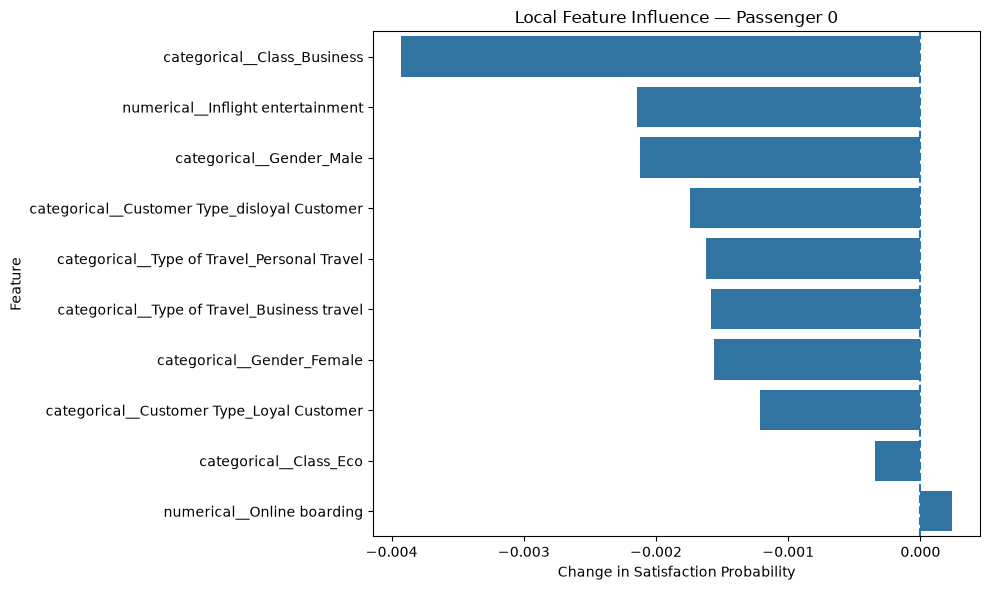

In [30]:
#Step 29: Visualizing the Individual Passenger Explanation
local_top = local_explanation_df.head(10).copy()

plt.figure(figsize=(10, 6))

sns.barplot(
    data=local_top,
    x="Probability_Change",
    y="Feature"
)

plt.axvline(
    0,
    linestyle="--"
)

plt.title(
    f"Local Feature Influence — Passenger {passenger_index}"
)

plt.xlabel("Change in Satisfaction Probability")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [31]:
#Step 30: Identifying Positive Influencing Features
positive_features = (
    local_explanation_df[
        local_explanation_df["Probability_Change"] > 0
    ]
    .head(10)
)

positive_features

,Feature,Original_Probability,Modified_Probability,Probability_Change,Absolute_Change
9,numerical__Online boarding,0.999758,1.000000,0.000242,0.000242
10,numerical__Inflight wifi service,0.999758,1.000000,0.000242,0.000242
11,numerical__Baggage handling,0.999758,1.000000,0.000242,0.000242
12,numerical__Inflight service,0.999758,1.000000,0.000242,0.000242
13,numerical__Cleanliness,0.999758,0.999988,0.000230,0.000230
15,numerical__Departure Delay in Minutes,0.999758,0.999972,0.000214,0.000214
17,numerical__Leg room service,0.999758,0.999957,0.000199,0.000199
19,numerical__Ease of Online booking,0.999758,0.999912,0.000154,0.000154
20,numerical__Departure/Arrival time convenient,0.999758,0.999909,0.000151,0.000151
21,numerical__Checkin service,0.999758,0.999852,0.000094,0.000094


In [32]:
#Step 31: Identifying Negative Influencing Features
negative_features = (
    local_explanation_df[
        local_explanation_df["Probability_Change"] < 0
    ]
    .sort_values(
        by="Probability_Change"
    )
    .head(10)
)

negative_features

,Feature,Original_Probability,Modified_Probability,Probability_Change,Absolute_Change
0,categorical__Class_Business,0.999758,0.995826,-0.003932,0.003932
1,numerical__Inflight entertainment,0.999758,0.997613,-0.002145,0.002145
2,categorical__Gender_Male,0.999758,0.997637,-0.002121,0.002121
3,categorical__Customer Type_disloyal Customer,0.999758,0.998019,-0.001740,0.001740
4,categorical__Type of Travel_Personal Travel,0.999758,0.998134,-0.001624,0.001624
5,categorical__Type of Travel_Business travel,0.999758,0.998171,-0.001587,0.001587
6,categorical__Gender_Female,0.999758,0.998200,-0.001558,0.001558
7,categorical__Customer Type_Loyal Customer,0.999758,0.998546,-0.001212,0.001212
8,categorical__Class_Eco,0.999758,0.999415,-0.000343,0.000343
14,numerical__Arrival Delay in Minutes,0.999758,0.999534,-0.000224,0.000224


In [33]:
#Step 32: Creating the Passenger Explanation Summary
passenger_explanation = pd.DataFrame({
    "Passenger_Index": [passenger_index],
    "Actual_Class": [actual_class],
    "Predicted_Class": [passenger_prediction],
    "Satisfaction_Probability": [passenger_probability]
})

passenger_explanation

,Passenger_Index,Actual_Class,Predicted_Class,Satisfaction_Probability
0,0,1,1,0.999758


In [34]:
#Step 33: Testing Multiple Passengers
sample_passengers = [0, 1, 2, 3, 4]

multi_passenger_results = []

for idx in sample_passengers:

    probability = predict_proba(
        X_test[idx:idx + 1]
    )[0]

    prediction = int(
        probability >= 0.5
    )

    multi_passenger_results.append({
        "Passenger_Index": idx,
        "Actual_Class": int(y_test[idx]),
        "Predicted_Class": prediction,
        "Satisfaction_Probability": probability
    })

multi_passenger_df = pd.DataFrame(
    multi_passenger_results
)

multi_passenger_df

,Passenger_Index,Actual_Class,Predicted_Class,Satisfaction_Probability
0,0,1,1,0.999758
1,1,1,1,1.000000
2,2,0,0,0.000420
3,3,1,1,1.000000
4,4,1,0,0.132873


In [35]:
#Step 34: Creating the Explainability Summary
summary_df = pd.DataFrame({
    "Metric": [
        "Number of Test Samples",
        "Explainability Sample Size",
        "Number of Features",
        "Test Accuracy",
        "Test Precision",
        "Test Recall",
        "Test F1"
    ],
    "Value": [
        len(X_test),
        len(X_explain),
        len(feature_names),
        accuracy,
        precision,
        recall,
        f1
    ]
})

summary_df

,Metric,Value
0,Number of Test Samples,25976.000000
1,Explainability Sample Size,5000.000000
2,Number of Features,27.000000
3,Test Accuracy,0.964121
4,Test Precision,0.971709
5,Test Recall,0.945804
6,Test F1,0.958581


In [36]:
#Step 35: Creating the Output Folder
output_dir = "../models/explainability"

os.makedirs(
    output_dir,
    exist_ok=True
)

print(
    "Output folder ready:",
    output_dir
)

Output folder ready: ../models/explainability


In [37]:
#Step 36: Saving Permutation Importance
importance_df.to_csv(
    f"{output_dir}/permutation_importance.csv",
    index=False
)

print("Permutation importance saved.")

Permutation importance saved.


In [38]:
#Step 37: Saving Top Features
top_features.to_csv(
    f"{output_dir}/top_features.csv",
    index=False
)

print("Top features saved.")

Top features saved.


In [39]:
#Step 38: Saving Passenger Explanations
multi_passenger_df.to_csv(
    f"{output_dir}/passenger_explanations.csv",
    index=False
)

print("Passenger explanations saved.")

Passenger explanations saved.


In [40]:
#Step 39: Saving the Explainability Summary
summary_df.to_csv(
    f"{output_dir}/explainability_summary.csv",
    index=False
)

print("Explainability summary saved.")

Explainability summary saved.


In [41]:
#Step 40: Verifying the Saved Files
expected_files = [
    "permutation_importance.csv",
    "top_features.csv",
    "passenger_explanations.csv",
    "explainability_summary.csv"
]

print("Saved files:\n")

for file_name in expected_files:

    file_path = os.path.join(
        output_dir,
        file_name
    )

    print(
        f"{file_name}:",
        "✓ Found"
        if os.path.exists(file_path)
        else "✗ Missing"
    )

Saved files:

permutation_importance.csv: ✓ Found
top_features.csv: ✓ Found
passenger_explanations.csv: ✓ Found
explainability_summary.csv: ✓ Found


In [42]:
#Step 41: Creating the Final Explainability Report
print("=" * 60)
print("AIRLINE SATISFACTION ANN — MODEL EXPLAINABILITY")
print("=" * 60)

print(f"\nTest Accuracy : {accuracy:.4f}")
print(f"Test Precision: {precision:.4f}")
print(f"Test Recall   : {recall:.4f}")
print(f"Test F1 Score : {f1:.4f}")

print("\nTop 10 Important Features:")

for rank, feature in enumerate(
    importance_df.head(10)["Feature"],
    start=1
):
    print(f"{rank}. {feature}")

print(
    "\nExplainability analysis completed successfully."
)

AIRLINE SATISFACTION ANN — MODEL EXPLAINABILITY

Test Accuracy : 0.9641
Test Precision: 0.9717
Test Recall   : 0.9458
Test F1 Score : 0.9586

Top 10 Important Features:
1. numerical__Inflight wifi service
2. categorical__Type of Travel_Personal Travel
3. numerical__Gate location
4. categorical__Customer Type_disloyal Customer
5. numerical__Baggage handling
6. numerical__Inflight service
7. numerical__Online boarding
8. numerical__Seat comfort
9. numerical__Checkin service
10. categorical__Class_Eco

Explainability analysis completed successfully.


#Step 42: Business Interpretation

## Final Business Interpretation

The ANN model does not make its predictions randomly.

Permutation importance identifies the features that have the greatest
impact on the model's predictive performance.

These important features can help the airline understand which aspects
of the passenger experience are most strongly associated with
satisfaction.

The results can support business decisions such as:

- Improving important service areas.
- Identifying factors associated with passenger dissatisfaction.
- Prioritizing customer-experience improvements.
- Understanding individual passenger predictions.
- Supporting targeted service improvements.

Important:

Feature importance shows which variables are influential for the model.
It does not by itself prove that a feature causes passenger satisfaction.